# Exp 4 - CNN architectures + transfer learning (CIFAR-10)

CS3807 Deep Learning Lab. Using ResNet50 pretrained on ImageNet, fine tuned on CIFAR-10.
Set the accelerator to GPU (T4 x2) under Settings before running. Using MirroredStrategy below so both GPUs actually get used.

Dataset used: **CIFAR-10 Python** (pickled batches format)
Link: https://www.kaggle.com/datasets/pankrzysiu/cifar10-python


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import time
import pickle
import os

print(tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs found:", gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# without a strategy keras only schedules work on gpu:0
strategy = tf.distribute.MirroredStrategy()
print("number of devices in strategy:", strategy.num_replicas_in_sync)

2.20.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
number of devices in strategy: 2


I0000 00:00:1787126665.548086      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787126665.551020      57 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
# constants kept in one place so the hyperparameter study later only needs edits here
IMG_SIZE = 96          # cifar arrives at 32x32 which is too small for resnet, so upscale a bit
BATCH_SIZE_PER_REPLICA = 32
BATCH_SIZE = BATCH_SIZE_PER_REPLICA * strategy.num_replicas_in_sync   # 64 with two gpus
EPOCHS_HEAD = 10
EPOCHS_FT = 8
LR_HEAD = 1e-3
LR_FT = 1e-5
NUM_CLASSES = 10
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("global batch size:", BATCH_SIZE)

# copy the exact path from the Input panel on the right of the kaggle notebook if yours differs
DATA_DIR = '/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py'

global batch size: 64


## Task 1 - dataset

In [ ]:
# kaggle hosts the raw pickled batches, not the npz that keras.datasets gives, so parse them by hand
def load_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data']
    labels = batch[b'labels']
    data = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # to NHWC
    return data, np.array(labels)

train_batches = [f'data_batch_{i}' for i in range(1, 6)]
x_train_list, y_train_list = [], []
for b in train_batches:
    xb, yb = load_batch(os.path.join(DATA_DIR, b))
    x_train_list.append(xb)
    y_train_list.append(yb)
x_train = np.concatenate(x_train_list)
y_train = np.concatenate(y_train_list)
x_test, y_test = load_batch(os.path.join(DATA_DIR, 'test_batch'))
print("train:", x_train.shape, y_train.shape)
print("test:", x_test.shape, y_test.shape)

train: (50000, 32, 32, 3) (50000,)
test: (10000, 32, 32, 3) (10000,)


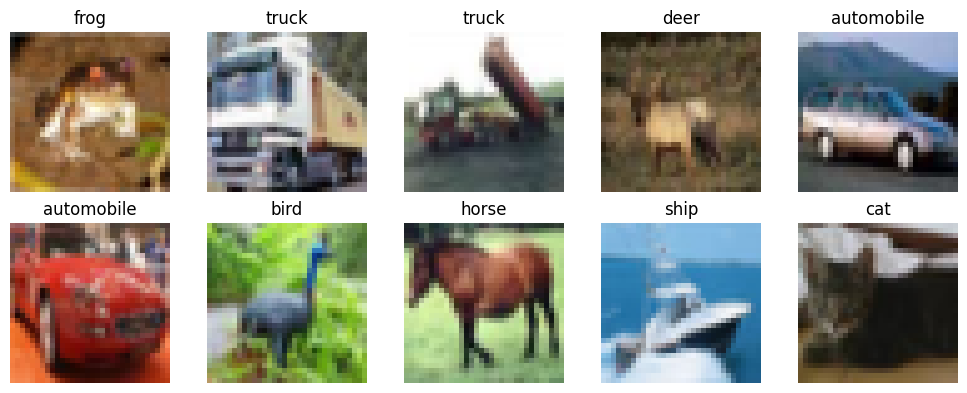

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# no manual sharding needed, once the model is built inside strategy.scope() keras divides each batch between replicas

## Task 2 - transfer learning model (ResNet50)

In [ ]:
# build inside the scope, that is the step that actually mirrors weights and gradients on both gpus
with strategy.scope():
    base_model = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False  # conv base stays frozen for the head phase

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.applications.resnet50.preprocess_input(inputs * 255.0)  # pipeline left pixels in 0-1, undo that here
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs)
    model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 96, 96, 3) │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ multiply[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 3, 3,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      2,570 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Task 3 - training the head

In [ ]:
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_HEAD),
        loss='sparse_categorical_crossentropy',   # sparse because y holds plain class indices, not one-hot
        metrics=['accuracy']
    )

start = time.time()
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS_HEAD)
head_train_time = time.time() - start
print(f"head training took {head_train_time/60:.1f} min")

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

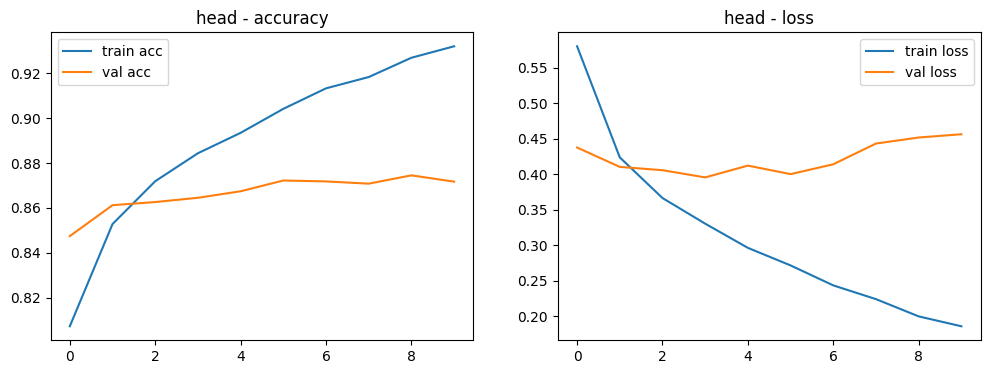

In [ ]:
def plot_history(hist, title_prefix=''):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='train acc')
    plt.plot(epochs_range, val_acc, label='val acc')
    plt.legend()
    plt.title(title_prefix + 'accuracy')
    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='train loss')
    plt.plot(epochs_range, val_loss, label='val loss')
    plt.legend()
    plt.title(title_prefix + 'loss')
    plt.show()

plot_history(history, 'head - ')

## Task 4 - fine tuning

Unfreezing the last block of ResNet50 and training a bit more with a much smaller lr so we don't wreck the pretrained weights.

In [ ]:
with strategy.scope():
    base_model.trainable = True
    # conv5 is roughly the last 30 layers, everything earlier stays frozen so the imagenet features survive
    fine_tune_at = len(base_model.layers) - 30
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FT),  # much smaller lr so the pretrained weights don't get wrecked
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

start = time.time()
history_ft = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS_FT)
ft_train_time = time.time() - start
print(f"fine tuning took {ft_train_time/60:.1f} min")

Epoch 1/8
INFO:tensorflow:Collective all_reduce tensors: 40 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 91ms/step - accuracy: 0.9864 - loss: 0.0451 - val_accuracy: 0.8944 - val_loss: 0.4356
Epoch 2/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.9891 - loss: 0.0363 - val_accuracy: 0.8963 - val_loss: 0.4431
Epoch 3/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.9909 - loss: 0.0321 - val_accuracy: 0.8953 - val_loss: 0.4547
Epoch 4/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.9919 - loss: 0.0274 - val_accuracy: 0.8960 - val_loss: 0.4616
Epoch 5/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.9935 - loss: 0.0227 - val_accuracy: 0.8974 - val_loss: 0.4698
Epoch 6/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.9940 - loss: 0.0204 - val_accuracy: 0.8980 - val_loss: 0.4771
Epoch 7/8
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 

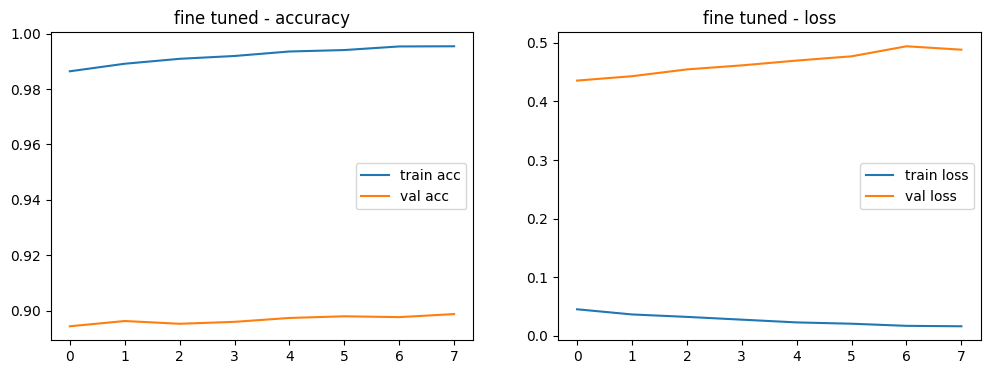

val accuracy before fine tuning: 0.8717
val accuracy after fine tuning:  0.8988


In [ ]:
plot_history(history_ft, 'fine tuned - ')
before_ft_acc = history.history['val_accuracy'][-1]
after_ft_acc = history_ft.history['val_accuracy'][-1]
print(f"val accuracy before fine tuning: {before_ft_acc:.4f}")
print(f"val accuracy after fine tuning:  {after_ft_acc:.4f}")

## Task 5 - evaluation

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"test accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# weighted averages, consistent with the classification report printed below
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"f1-score:  {f1:.4f}")

total_params = model.count_params()
print(f"total params: {total_params:,}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8988 - loss: 0.4884
test accuracy: 0.8988
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step
precision: 0.8989
recall:    0.8988
f1-score:  0.8988
total params: 24,114,826


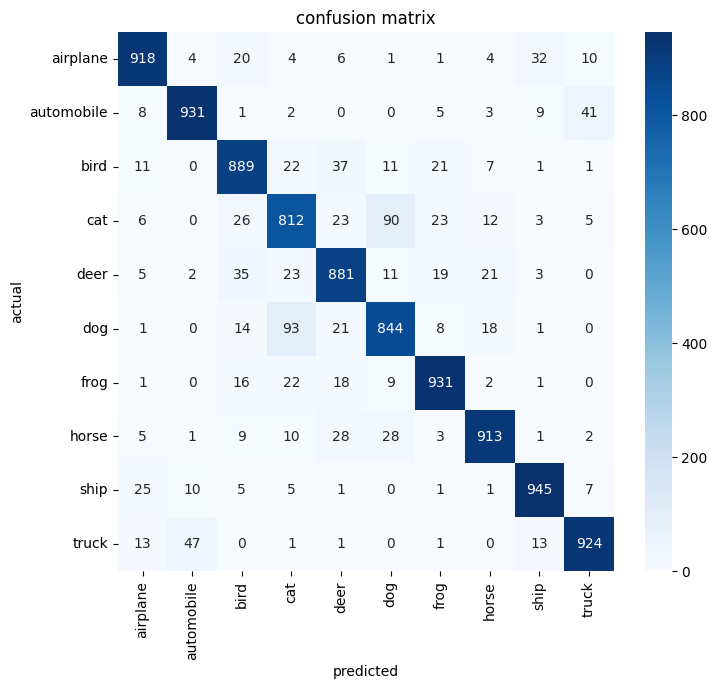

              precision    recall  f1-score   support

    airplane       0.92      0.92      0.92      1000
  automobile       0.94      0.93      0.93      1000
        bird       0.88      0.89      0.88      1000
         cat       0.82      0.81      0.81      1000
        deer       0.87      0.88      0.87      1000
         dog       0.85      0.84      0.85      1000
        frog       0.92      0.93      0.92      1000
       horse       0.93      0.91      0.92      1000
        ship       0.94      0.94      0.94      1000
       truck       0.93      0.92      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()
print(classification_report(y_test, y_pred, target_names=class_names))

### misclassified samples (optional plot from the manual)

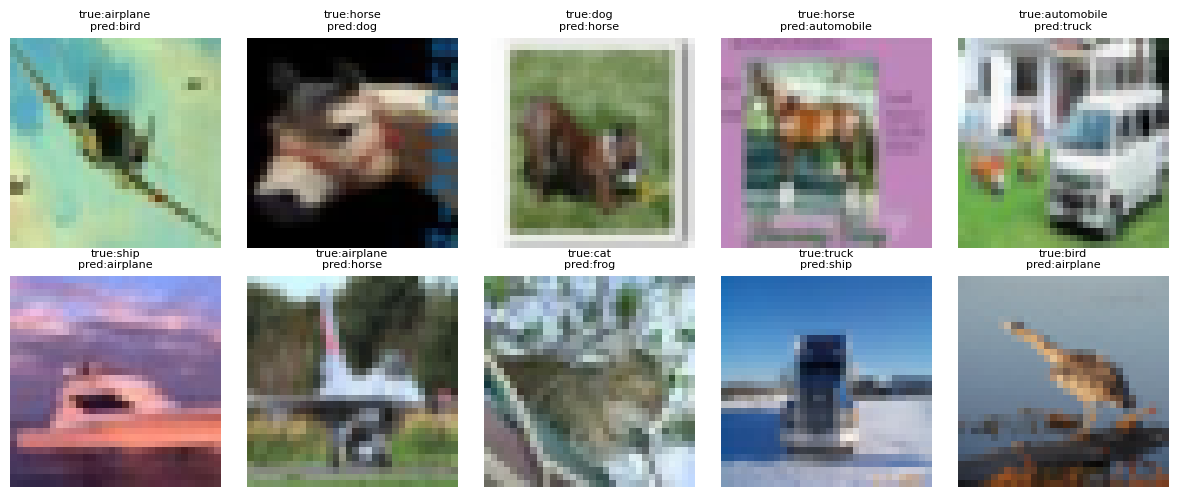

In [ ]:
# quick look at what actually gets misclassified
wrong_idx = np.where(y_pred != y_test)[0]
sample_wrong = np.random.choice(wrong_idx, size=10, replace=False)
plt.figure(figsize=(12,5))
for i, idx in enumerate(sample_wrong):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"true:{class_names[y_test[idx]]}\npred:{class_names[y_pred[idx]]}", fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# comparison table, the resnet row goes in first using the numbers already computed above
import pandas as pd
comparison_results = []
comparison_results.append({
    'model': 'ResNet50',
    'params': total_params,
    'accuracy': test_acc,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'train_time_min': (head_train_time + ft_train_time) / 60
})
comparison_results

[{'model': 'ResNet50',
  'params': 24114826,
  'accuracy': 0.8988000154495239,
  'precision': 0.8988773212095835,
  'recall': 0.8988,
  'f1': 0.8988084673549814,
  'train_time_min': 15.63129429022471}]

In [ ]:
# one helper so the same train/eval block isn't copy pasted four more times
def train_and_evaluate(model, name, epochs):
    with strategy.scope():
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    start = time.time()
    hist = model.fit(train_ds, validation_data=test_ds, epochs=epochs, verbose=1)
    elapsed = time.time() - start

    y_pred_probs = model.predict(test_ds)
    y_pred_local = np.argmax(y_pred_probs, axis=1)
    acc = model.evaluate(test_ds, verbose=0)[1]
    prec = precision_score(y_test, y_pred_local, average='weighted')
    rec = recall_score(y_test, y_pred_local, average='weighted')
    f1_local = f1_score(y_test, y_pred_local, average='weighted')

    comparison_results.append({
        'model': name,
        'params': model.count_params(),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1_local,
        'train_time_min': elapsed / 60
    })
    print(f"{name} -> acc: {acc:.4f}, params: {model.count_params():,}, time: {elapsed/60:.1f} min")
    return hist

In [ ]:
# LeNet-5 built from scratch, no pretrained weights exist for this one
EPOCHS_SCRATCH = 15   # scratch models need a few more epochs than the transfer learning ones
with strategy.scope():
    lenet = tf.keras.Sequential([
        tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(6, 5, activation='relu', padding='same'),
        tf.keras.layers.AveragePooling2D(2),
        tf.keras.layers.Conv2D(16, 5, activation='relu'),
        tf.keras.layers.AveragePooling2D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='relu'),
        tf.keras.layers.Dense(84, activation='relu'),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
train_and_evaluate(lenet, 'LeNet-5', EPOCHS_SCRATCH)

Epoch 1/15
INFO:tensorflow:Collective all_reduce tensors: 10 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4277 - loss: 1.5741 - val_accuracy: 0.5259 - val_loss: 1.2999
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5771 - loss: 1.1862 - val_accuracy: 0.5844 - val_loss: 1.1684
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.6379 - loss: 1.0201 - val_accuracy: 0.6212 - val_loss: 1.0905
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.6885 - loss: 0.8811 - val_accuracy: 0.6212 - val_loss: 1.1022
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7297 - loss: 0.7668 - val_accuracy: 0.6262 - val_loss: 1.1314
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7666 - loss: 0.6624 - val_accuracy: 0.6373 - val_loss: 1.1259
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - acc

In [ ]:
# AlexNet, squeezed down to 96x96 instead of the original 227x227
with strategy.scope():
    alexnet = tf.keras.Sequential([
        tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(64, 7, strides=2, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(3, strides=2, padding='same'),
        tf.keras.layers.Conv2D(192, 5, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(3, strides=2, padding='same'),
        tf.keras.layers.Conv2D(384, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(3, strides=2, padding='same'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
train_and_evaluate(alexnet, 'AlexNet', EPOCHS_SCRATCH)

Epoch 1/15
INFO:tensorflow:Collective all_reduce tensors: 16 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 119ms/step - accuracy: 0.1011 - loss: 2.3121 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.0982 - loss: 2.3030 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.0971 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/step - accuracy: 0.0981 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.0985 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 117ms/step - accuracy: 0.0966 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 92s 118ms/ste

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# VGG16, frozen base with the same head pattern as the resnet model
with strategy.scope():
    vgg_base = tf.keras.applications.VGG16(
        weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    vgg_base.trainable = False
    inp = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    xv = tf.keras.applications.vgg16.preprocess_input(inp * 255.0)
    xv = vgg_base(xv, training=False)
    xv = tf.keras.layers.GlobalAveragePooling2D()(xv)
    xv = tf.keras.layers.Dense(256, activation='relu')(xv)
    xv = tf.keras.layers.Dropout(0.3)(xv)
    out_v = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(xv)
    vgg_model = tf.keras.Model(inp, out_v)
train_and_evaluate(vgg_model, 'VGG16', EPOCHS_HEAD)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - accuracy: 0.7291 - loss: 0.9326 - val_accuracy: 0.8077 - val_loss: 0.5694
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8143 - loss: 0.5424 - val_accuracy: 0.8137 - val_loss: 0.5362
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8351 - loss: 0.4757 - val_accuracy: 0.8257 - val_loss: 0.5065
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8502 - loss: 0.4316 - val_accuracy: 0.8287 - val_loss: 0.5015
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8619 - loss: 0.3917 - val_accuracy: 0.8274 - val_loss: 0.5076
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.8714 - loss: 0.3635 - val_accuracy: 0.8295 - val_loss: 0.5205
Epoch 7/1

In [ ]:
# keras doesn't ship the original GoogleNet, InceptionV3 is the same inception idea in its modern form
with strategy.scope():
    inception_base = tf.keras.applications.InceptionV3(
        weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    inception_base.trainable = False
    inp_i = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    xi = tf.keras.applications.inception_v3.preprocess_input(inp_i * 255.0)
    xi = inception_base(xi, training=False)
    xi = tf.keras.layers.GlobalAveragePooling2D()(xi)
    xi = tf.keras.layers.Dense(256, activation='relu')(xi)
    xi = tf.keras.layers.Dropout(0.3)(xi)
    out_i = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(xi)
    inception_model = tf.keras.Model(inp_i, out_i)
train_and_evaluate(inception_model, 'GoogleNet (InceptionV3)', EPOCHS_HEAD)

Epoch 1/10
INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.6097 - loss: 1.1402 - val_accuracy: 0.6914 - val_loss: 0.9169
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.6868 - loss: 0.9126 - val_accuracy: 0.6966 - val_loss: 0.8818
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7083 - loss: 0.8374 - val_accuracy: 0.6993 - val_loss: 0.8704
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7257 - loss: 0.7871 - val_accuracy: 0.7052 - val_loss: 0.8622
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7397 - loss: 0.7407 - val_accuracy: 0.7039 - val_loss: 0.8664
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accuracy: 0.7560 - loss: 0.6941 - val_accuracy: 0.7081 - val_loss: 0.8721
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step - accu

                  model   params  accuracy  precision  recall       f1  train_time_min
               ResNet50 24114826    0.8988   0.898877  0.8988 0.898808       15.631294
                LeNet-5   943286    0.6028   0.606013  0.6028 0.599441        3.192582
                AlexNet 57030986    0.1000   0.010000  0.1000 0.018182       23.139157
                  VGG16 14848586    0.8258   0.826666  0.8258 0.824682        6.757113
GoogleNet (InceptionV3) 22329898    0.7048   0.707801  0.7048 0.704910        4.815094
GoogleNet (InceptionV3) 22329898    0.7063   0.707475  0.7063 0.705600        4.806501


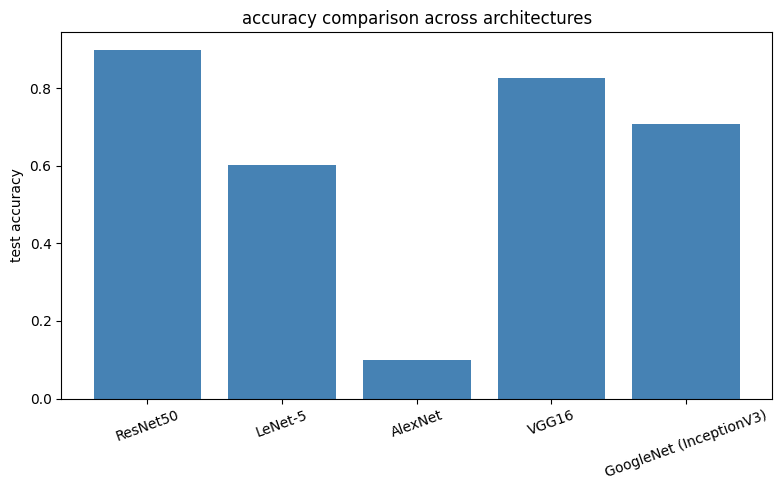

In [ ]:
# section 18.2 comparison table plus the accuracy bar chart
df = pd.DataFrame(comparison_results)
df = df[['model', 'params', 'accuracy', 'precision', 'recall', 'f1', 'train_time_min']]
print(df.to_string(index=False))

plt.figure(figsize=(8,5))
plt.bar(df['model'], df['accuracy'], color='steelblue')
plt.ylabel('test accuracy')
plt.title('accuracy comparison across architectures')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
# section 18.1 metrics table for the resnet run
final_train_acc = history_ft.history['accuracy'][-1]   # last epoch of fine tuning
metrics_table = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy', 'Precision', 'Recall',
               'F1-score', 'Training Time (min)', 'Total Parameters'],
    'Value': [
        f"{final_train_acc:.4f}",
        f"{test_acc:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{(head_train_time + ft_train_time)/60:.1f}",
        f"{total_params:,}"
    ]
})
print(metrics_table.to_string(index=False))

             Metric      Value
  Training Accuracy     0.9954
   Testing Accuracy     0.8988
          Precision     0.8989
             Recall     0.8988
           F1-score     0.8988
Training Time (min)       15.6
   Total Parameters 24,114,826
